In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

# 1. Встановлення частотності

## Zabrodin_file_4.txt - Самостійні частини мови

Фільтрація файлу з парами `[слово] [POS-Tag]` від слів неповнозначних частин мови. Відповідники українських частин мов у Universal POS-Tags було визначено за [https://universaldependencies.org/uk/pos/](https://universaldependencies.org/uk/pos/).

In [2]:
INPUT_FILE = "../lab01/Zabrodin_file_3.txt"
OUTPUT_FILE = "Zabrodin_file_4.txt"

independent_pos_tags = {"ADJ", "ADV", "NOUN", "PROPN", "VERB", "AUX", "DET", "NUM", "PRON"}
filtered_lines = []

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()

        word = parts[0]
        pos_tag = parts[1]

        if pos_tag in independent_pos_tags:
            filtered_lines.append(f"{word} {pos_tag}\n")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    f.writelines(filtered_lines)

### Bar Chart - Топ-20 слів самостійних частин мов за частотою

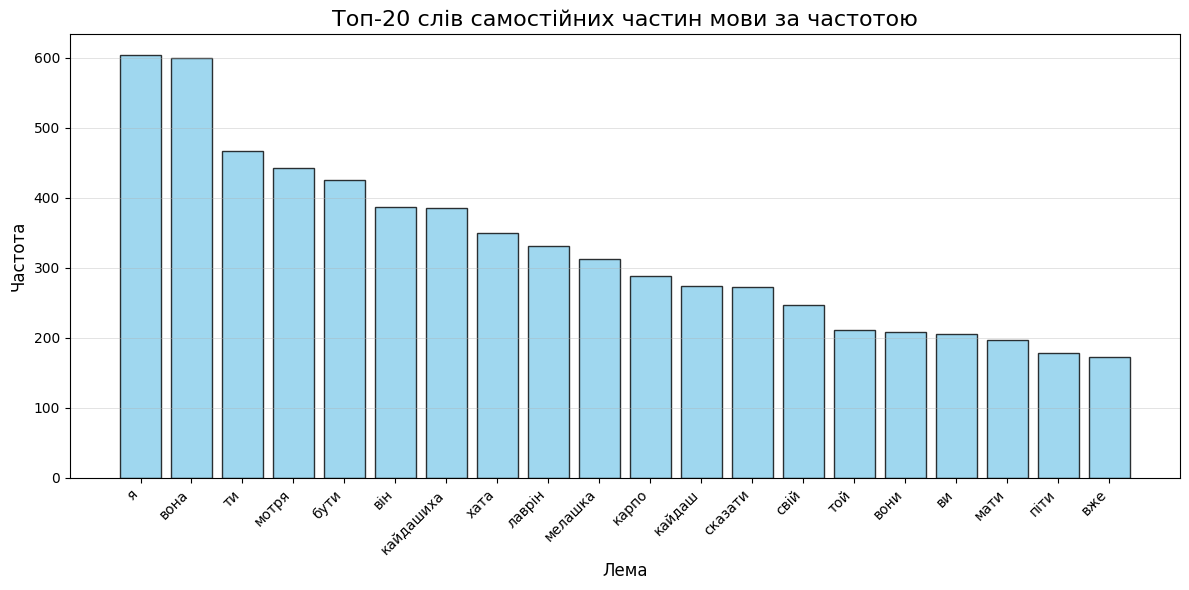

In [3]:
INPUT_FILE = "Zabrodin_file_4.txt"
OUTPUT_IMAGE = "Zabrodin_top_20.png"

words = []

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    for line in f:
        words.append(line.strip().split()[0].lower())

TOP_N = 20
top_N = Counter(words).most_common(TOP_N)
lemma, frequency = zip(*top_N)

plt.figure(figsize=(12, 6))
plt.bar(lemma, frequency, color='skyblue', edgecolor='black', alpha=0.8)

plt.title(f"Топ-{TOP_N} слів самостійних частин мови за частотою", fontsize=16)
plt.xlabel("Лема", fontsize=12)
plt.ylabel("Частота", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='-', alpha=0.5)
plt.tight_layout()

plt.savefig(OUTPUT_IMAGE, format='png', transparent=True, dpi=300)

plt.show()

## Закон Зіпфа

$$f = C \cdot rank^\alpha$$
$$\log(f) = \log(C \cdot rank^\alpha)$$
$$\log(f) = \log(C) + \log(rank^\alpha)$$
$$\log(f) = \log(C) + \alpha \cdot \log(rank)$$

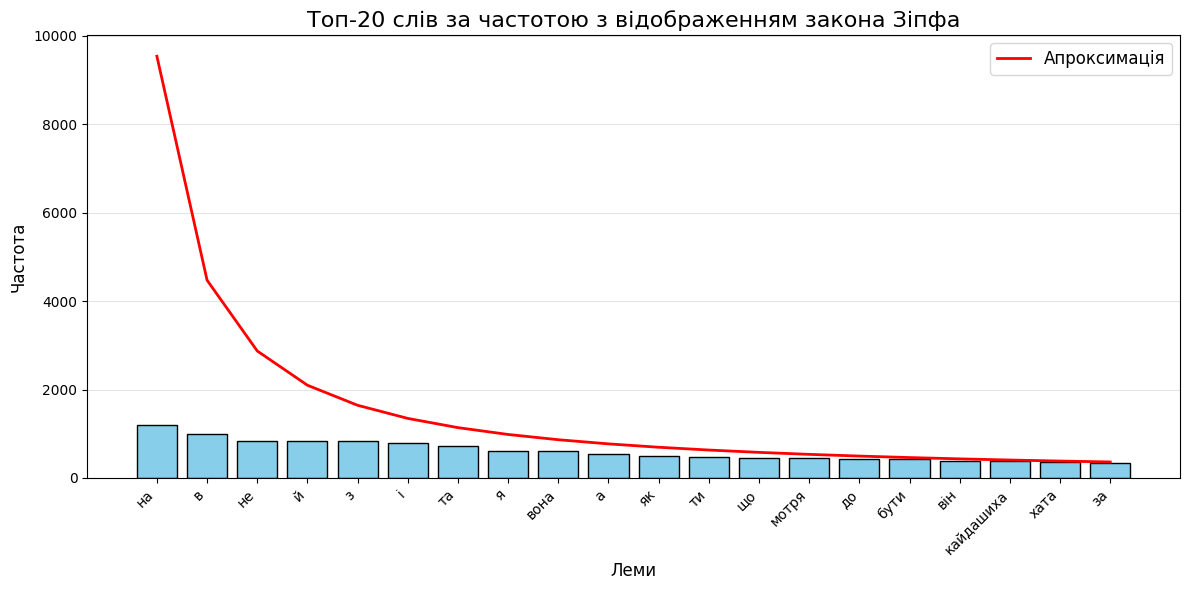

In [4]:
INPUT_FILE = "../lab01/Zabrodin_file_3.txt"
OUTPUT_IMAGE = "Zabrodin_zipf_law.png"

words = []
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    for line in f:
        words.append(line.strip().split()[0].lower())

top_N = Counter(words).most_common()

all_frequencies = np.array([count for _, count in top_N])
all_ranks = np.arange(1, len(all_frequencies) + 1)

log_ranks = np.log(all_ranks)  # log(rank)
log_frequencies = np.log(all_frequencies)  # log(f)
alpha, log_C = np.polyfit(log_ranks, log_frequencies, 1)  # alpha & log(C)
C = np.exp(log_C)  # C

TOP_N = 20
top_words = np.array([word for word, _ in top_N[:TOP_N]])
top_frequencies = all_frequencies[:TOP_N]
top_ranks = all_ranks[:TOP_N]

approximate_frequencies = C * (top_ranks ** alpha)  # f = C * rank^alpha

plt.figure(figsize=(12, 6))
plt.bar(top_words, top_frequencies, color='skyblue', edgecolor='black')
plt.plot(top_words, approximate_frequencies, color='red', linewidth=2, label=f"Апроксимація")

plt.title(f"Топ-{TOP_N} слів за частотою з відображенням закона Зіпфа", fontsize=16)
plt.xlabel("Леми", fontsize=12)
plt.ylabel("Частота", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='-', alpha=0.5)
plt.tight_layout()

plt.savefig(OUTPUT_IMAGE, format='png', transparent=True, dpi=300)

plt.show()

## Закон Гіпса

$$V = K \cdot n^\beta$$
$$\log(V) = \log(K \cdot n^\beta)$$
$$\log(V) = \log(K) + \log(n^\beta)$$
$$\log(V) = \log(K) + \beta \cdot \log(n)$$

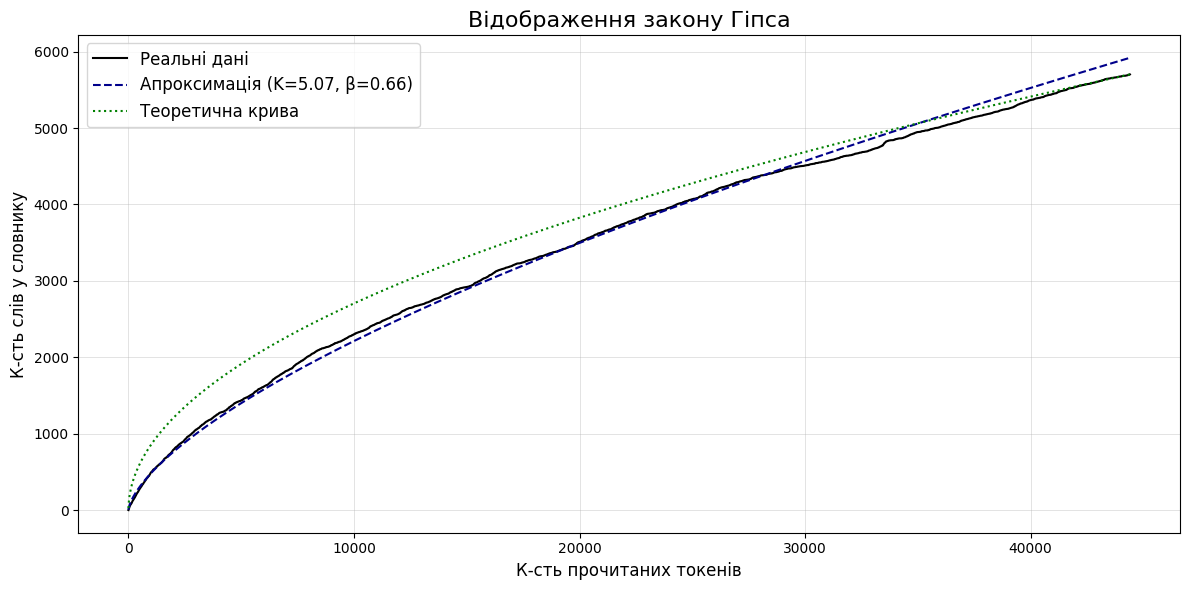

In [5]:
INPUT_FILE = "../lab01/Zabrodin_file_3.txt"
OUTPUT_IMAGE = "Zabrodin_heaps_law.png"

words = []
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    for line in f:
        words.append(line.strip().split()[0].lower())

token_counts = []
vocab_sizes = []
unique_words = set()

for i, word in enumerate(words):
    unique_words.add(word)
    token_counts.append(i + 1)
    vocab_sizes.append(len(unique_words))

token_counts = np.array(token_counts)
vocab_sizes = np.array(vocab_sizes)

log_n = np.log(token_counts)  # log(n)
log_V = np.log(vocab_sizes)  # log(V)
beta, log_K = np.polyfit(log_n, log_V, 1)  # beta & log(K)
K = np.exp(log_K)  # K

V_approximate = K * (token_counts ** beta)  # V = K * n^beta

beta_theoretical = 0.5
K_theoretical = vocab_sizes[-1] / (token_counts[-1] ** beta_theoretical)  # k = V/n^beta
V_theoretical = K_theoretical * (token_counts ** beta_theoretical)  # V = k * n^beta

plt.figure(figsize=(12, 6))

plt.plot(token_counts, vocab_sizes, color='black', label="Реальні дані")
plt.plot(token_counts, V_approximate, color='darkblue', linestyle='--', label=f"Апроксимація (K={K:.2f}, β={beta:.2f})")
plt.plot(token_counts, V_theoretical, color='green', linestyle=':', label=f"Теоретична крива")

plt.title("Відображення закону Гіпса", fontsize=16)
plt.xlabel("К-сть прочитаних токенів", fontsize=12)
plt.ylabel("К-сть слів у словнику", fontsize=12)
plt.legend(fontsize=12)
plt.grid(linestyle='-', alpha=0.5)
plt.tight_layout()

plt.savefig(OUTPUT_IMAGE, format='png', transparent=True, dpi=300)

plt.show()